# Task 8-1: Conditional Variational Autoencoder (CVAE) — Flowers Dataset

**TIES 4911 (2026)**

Based on: https://www.tensorflow.org/tutorials/generative/cvae

**Dataset:** `tf_flowers` — 5 classes of flowers (daisy, dandelion, roses, sunflowers, tulips) — ~3,670 images.

**Goal:** Train a CVAE conditioned on flower class labels. After training, generate images per class by sampling from the latent space and feeding a class label to the decoder.

## 1. Imports & Setup

In [1]:
!pip install tensorflow-datasets keras-cv -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 20.0 MB/s eta 0:00:00


In [2]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow import keras
from tensorflow.keras import layers

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

TensorFlow version: 2.20.0
GPU available: []


## 2. Dataset — tf_flowers

The `tf_flowers` dataset contains 3,670 flower photos across 5 classes:
- 0: daisy
- 1: dandelion
- 2: roses
- 3: sunflowers
- 4: tulips

Images are resized to **64×64×3** for training.

In [3]:
IMAGE_SIZE = 64
BATCH_SIZE = 32
NUM_CLASSES = 5
CLASS_NAMES = ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']

def preprocess(image, label):
    """Resize, normalize to [0, 1], and one-hot encode label."""
    image = tf.image.resize(image, [IMAGE_SIZE, IMAGE_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    label = tf.one_hot(label, NUM_CLASSES)
    return image, label

# Load dataset (auto-downloads ~200 MB)
(ds_train, ds_test), ds_info = tfds.load(
    'tf_flowers',
    split=['train[:80%]', 'train[80%:]'],
    as_supervised=True,
    with_info=True
)

train_dataset = (
    ds_train
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    ds_test
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print(f'Train batches: {len(train_dataset)}, Test batches: {len(test_dataset)}')

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.F28Q6W_3.0.1/tf_flowers-train.tfrecord*...:   0%|   …

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.
Train batches: 92, Test batches: 23


### Visualize sample images

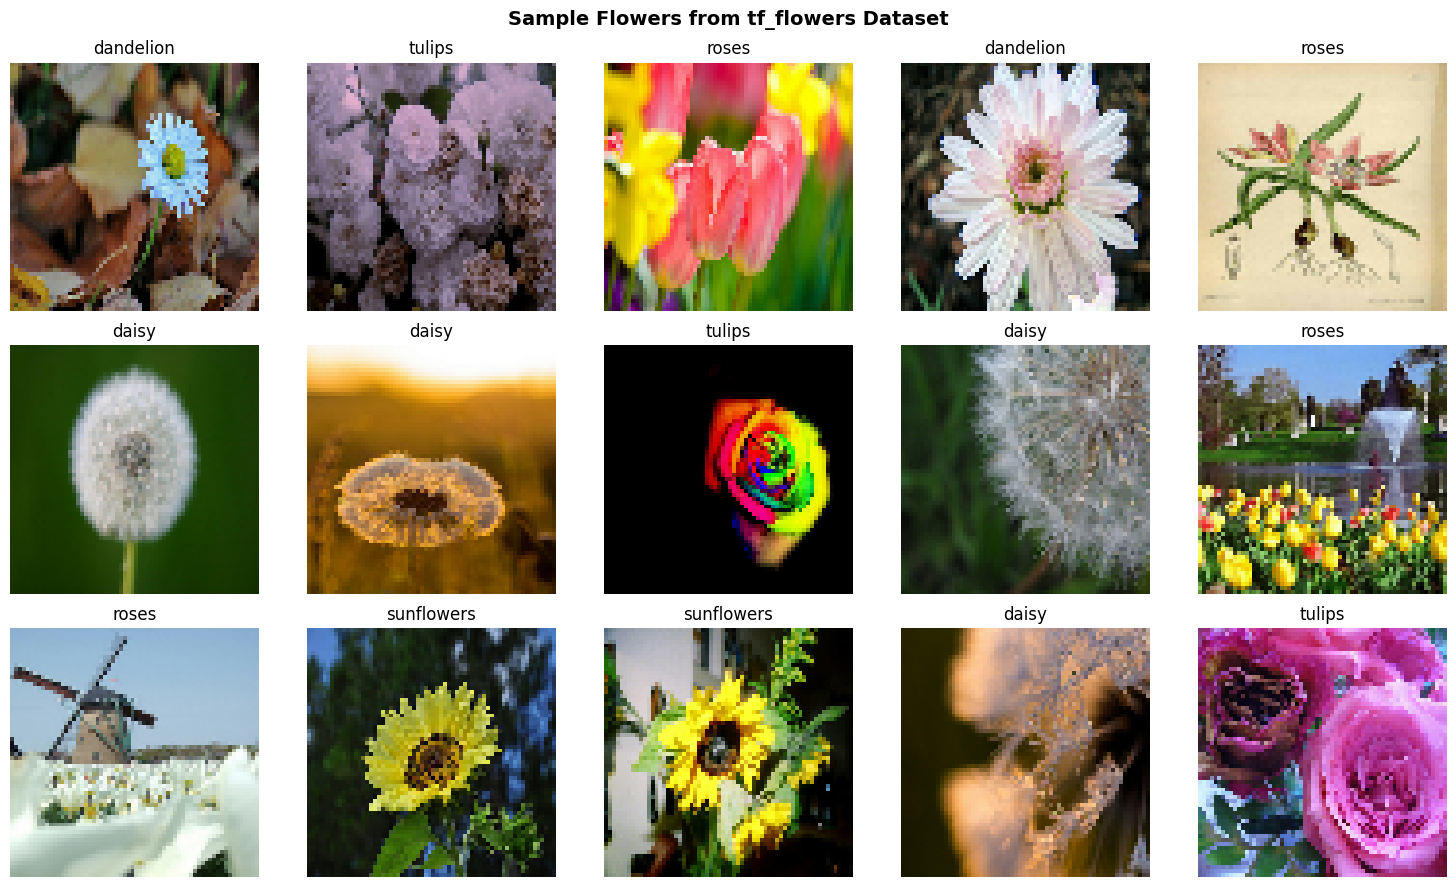

Dataset sample visualized.


In [4]:
sample_images, sample_labels = next(iter(train_dataset))

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
for i, ax in enumerate(axes.flat):
    ax.imshow(sample_images[i].numpy())
    ax.set_title(CLASS_NAMES[tf.argmax(sample_labels[i]).numpy()])
    ax.axis('off')
plt.suptitle('Sample Flowers from tf_flowers Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cvae_sample_data.png', dpi=100, bbox_inches='tight')
plt.show()
print('Dataset sample visualized.')

## 3. CVAE Model Architecture

A **Conditional VAE** extends the standard VAE by conditioning both the encoder and decoder on class labels.

- **Encoder**: takes an image + class label → outputs mean (μ) and log-variance (log σ²) of the latent distribution
- **Reparameterization**: z = μ + σ × ε, where ε ~ N(0, I)
- **Decoder**: takes z + class label → reconstructs the image

At generation time, we sample z ~ N(0, I) and pass a desired class label to generate class-specific images.

In [5]:
LATENT_DIM = 128

class Encoder(keras.Model):
    """Maps (image, label) -> (z_mean, z_log_var)"""
    def __init__(self, latent_dim):
        super().__init__()
        # Image pathway
        self.conv1 = layers.Conv2D(32, 3, strides=2, padding='same')
        self.conv2 = layers.Conv2D(64, 3, strides=2, padding='same')
        self.conv3 = layers.Conv2D(128, 3, strides=2, padding='same')
        self.bn1 = layers.BatchNormalization()
        self.bn2 = layers.BatchNormalization()
        self.bn3 = layers.BatchNormalization()
        self.flatten = layers.Flatten()
        # Label embedding
        self.label_embed = layers.Dense(64, activation='relu')
        # Latent projections
        self.dense_common = layers.Dense(512, activation='relu')
        self.z_mean = layers.Dense(latent_dim)
        self.z_log_var = layers.Dense(latent_dim)

    def call(self, inputs, training=False):
        image, label = inputs
        # Encode image
        x = tf.nn.leaky_relu(self.bn1(self.conv1(image), training=training))
        x = tf.nn.leaky_relu(self.bn2(self.conv2(x), training=training))
        x = tf.nn.leaky_relu(self.bn3(self.conv3(x), training=training))
        x = self.flatten(x)
        # Encode label
        l = self.label_embed(label)
        # Fuse image + label features
        x = tf.concat([x, l], axis=-1)
        x = self.dense_common(x)
        return self.z_mean(x), self.z_log_var(x)


class Decoder(keras.Model):
    """Maps (z, label) -> reconstructed image"""
    def __init__(self, latent_dim):
        super().__init__()
        # Label embedding
        self.label_embed = layers.Dense(64, activation='relu')
        # Project to spatial tensor
        self.dense = layers.Dense(8 * 8 * 128, activation='relu')
        self.reshape = layers.Reshape((8, 8, 128))
        # Upsampling layers
        self.deconv1 = layers.Conv2DTranspose(128, 3, strides=2, padding='same')
        self.deconv2 = layers.Conv2DTranspose(64, 3, strides=2, padding='same')
        self.deconv3 = layers.Conv2DTranspose(32, 3, strides=2, padding='same')
        self.deconv_out = layers.Conv2DTranspose(3, 3, padding='same', activation='sigmoid')
        self.bn1 = layers.BatchNormalization()
        self.bn2 = layers.BatchNormalization()
        self.bn3 = layers.BatchNormalization()

    def call(self, inputs, training=False):
        z, label = inputs
        l = self.label_embed(label)
        x = tf.concat([z, l], axis=-1)
        x = self.dense(x)
        x = self.reshape(x)
        x = tf.nn.relu(self.bn1(self.deconv1(x), training=training))
        x = tf.nn.relu(self.bn2(self.deconv2(x), training=training))
        x = tf.nn.relu(self.bn3(self.deconv3(x), training=training))
        return self.deconv_out(x)


class CVAE(keras.Model):
    """Conditional Variational Autoencoder"""
    def __init__(self, latent_dim):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparameterize(self, mean, log_var):
        eps = tf.random.normal(shape=tf.shape(mean))
        return mean + tf.exp(0.5 * log_var) * eps

    def encode(self, image, label, training=False):
        return self.encoder([image, label], training=training)

    def decode(self, z, label, training=False):
        return self.decoder([z, label], training=training)

    def call(self, inputs, training=False):
        image, label = inputs
        z_mean, z_log_var = self.encode(image, label, training=training)
        z = self.reparameterize(z_mean, z_log_var)
        reconstruction = self.decode(z, label, training=training)
        return reconstruction, z_mean, z_log_var

cvae = CVAE(LATENT_DIM)
optimizer = keras.optimizers.Adam(learning_rate=1e-3)
print('CVAE model created.')

CVAE model created.


## 4. Loss Function — ELBO

The VAE is trained to maximize the **Evidence Lower Bound (ELBO)**:

$$\mathcal{L} = \mathbb{E}_{q(z|x,c)}[\log p(x|z,c)] - D_{KL}(q(z|x,c) \| p(z))$$

- **Reconstruction loss**: Binary cross-entropy between input and output pixels
- **KL divergence**: Regularizes the latent space toward N(0, I)

In [6]:
def compute_loss(model, images, labels, training=False):
    reconstruction, z_mean, z_log_var = model([images, labels], training=training)

    # Reconstruction loss (pixel-wise binary cross-entropy, summed then averaged)
    recon_loss = tf.reduce_mean(
        tf.reduce_sum(
            keras.losses.binary_crossentropy(images, reconstruction),
            axis=(1, 2)
        )
    )

    # KL divergence: -0.5 * sum(1 + log_var - mean^2 - exp(log_var))
    kl_loss = -0.5 * tf.reduce_mean(
        tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
    )

    return recon_loss + kl_loss


@tf.function
def train_step(model, images, labels, optimizer):
    with tf.GradientTape() as tape:
        loss = compute_loss(model, images, labels, training=True)
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return loss

print('Loss function and training step defined.')

Loss function and training step defined.


## 5. Training

In [7]:
EPOCHS = 60

train_losses = []
test_losses = []

# Fixed test samples for visualization across epochs
test_images, test_labels = next(iter(test_dataset))
fixed_images = test_images[:5]
fixed_labels = test_labels[:5]

print(f'Training CVAE for {EPOCHS} epochs...')
start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    epoch_loss = []
    for images, labels in train_dataset:
        loss = train_step(cvae, images, labels, optimizer)
        epoch_loss.append(loss.numpy())

    mean_train_loss = np.mean(epoch_loss)
    train_losses.append(mean_train_loss)

    # Test loss
    test_epoch_loss = []
    for images, labels in test_dataset:
        test_epoch_loss.append(compute_loss(cvae, images, labels).numpy())
    mean_test_loss = np.mean(test_epoch_loss)
    test_losses.append(mean_test_loss)

    if epoch % 10 == 0:
        elapsed = time.time() - start_time
        print(f'Epoch {epoch:3d}/{EPOCHS} | Train Loss: {mean_train_loss:.2f} | Test Loss: {mean_test_loss:.2f} | Time: {elapsed:.1f}s')

print(f'Training complete in {time.time() - start_time:.1f}s')

Training CVAE for 60 epochs...
Epoch  10/60 | Train Loss: 2302.61 | Test Loss: 2294.95 | Time: 664.9s
Epoch  20/60 | Train Loss: 2274.05 | Test Loss: 2279.19 | Time: 1331.1s
Epoch  30/60 | Train Loss: 2258.59 | Test Loss: 2261.44 | Time: 1972.5s
Epoch  40/60 | Train Loss: 2248.29 | Test Loss: 2267.71 | Time: 2611.6s
Epoch  50/60 | Train Loss: 2239.09 | Test Loss: 2277.01 | Time: 3276.3s
Epoch  60/60 | Train Loss: 2231.53 | Test Loss: 2282.04 | Time: 3910.8s
Training complete in 3910.8s


## 6. Training Loss Curve

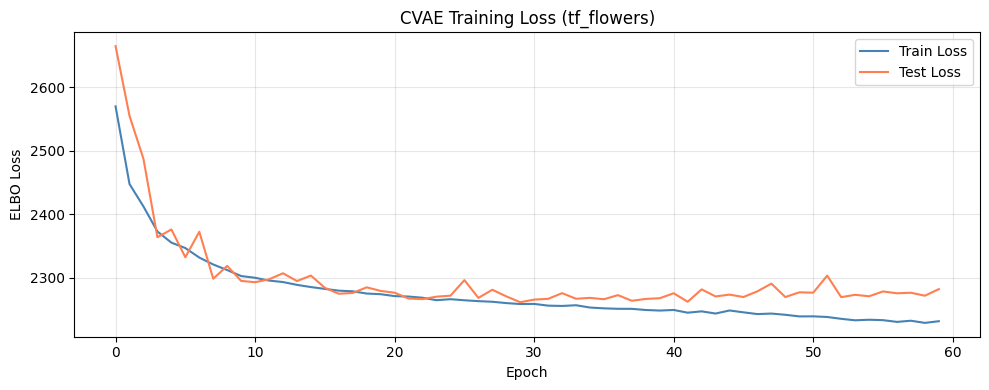

In [8]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss', color='steelblue')
plt.plot(test_losses, label='Test Loss', color='coral')
plt.xlabel('Epoch')
plt.ylabel('ELBO Loss')
plt.title('CVAE Training Loss (tf_flowers)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cvae_loss_curve.png', dpi=100, bbox_inches='tight')
plt.show()

## 7. Image Reconstruction

Compare original images (top row) with their reconstructions (bottom row) on the test set.

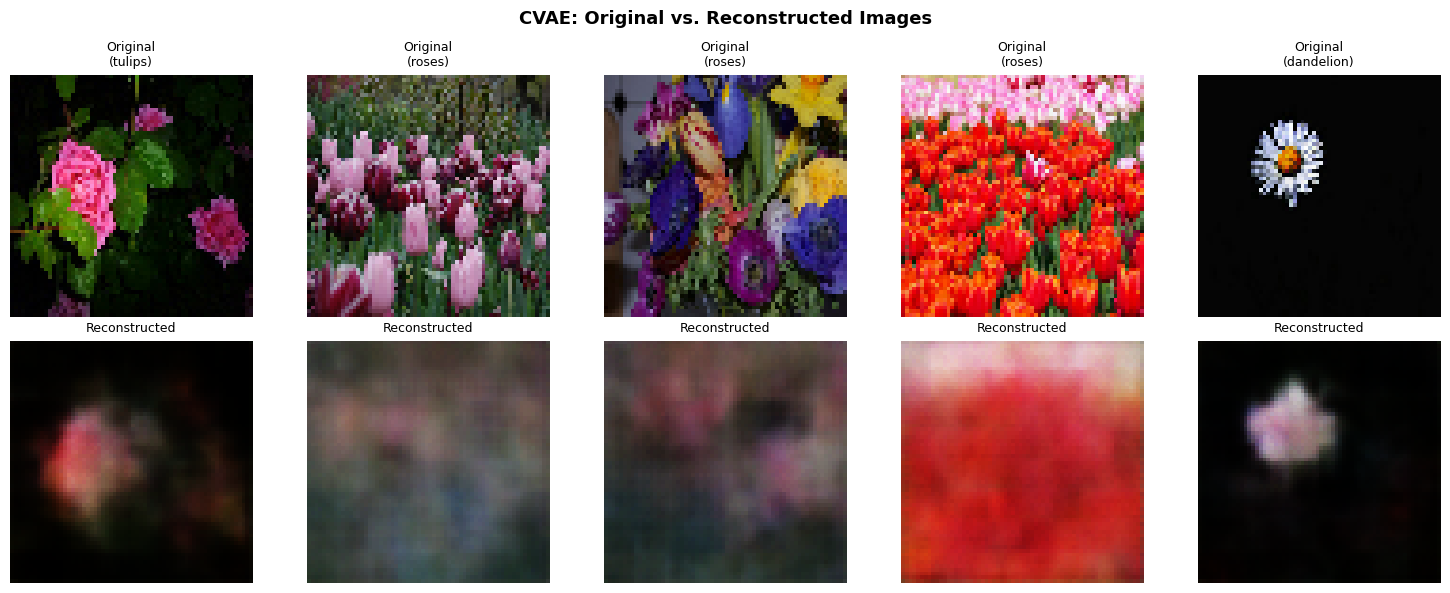

In [9]:
reconstructions, _, _ = cvae([fixed_images, fixed_labels], training=False)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(5):
    cls = CLASS_NAMES[tf.argmax(fixed_labels[i]).numpy()]
    axes[0, i].imshow(fixed_images[i].numpy())
    axes[0, i].set_title(f'Original\n({cls})', fontsize=9)
    axes[0, i].axis('off')
    axes[1, i].imshow(reconstructions[i].numpy())
    axes[1, i].set_title('Reconstructed', fontsize=9)
    axes[1, i].axis('off')

plt.suptitle('CVAE: Original vs. Reconstructed Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cvae_reconstructions.png', dpi=100, bbox_inches='tight')
plt.show()

## 8. Conditional Image Generation

Generate new images for each flower class by:
1. Sampling z ~ N(0, I)
2. Providing a one-hot class label to the decoder

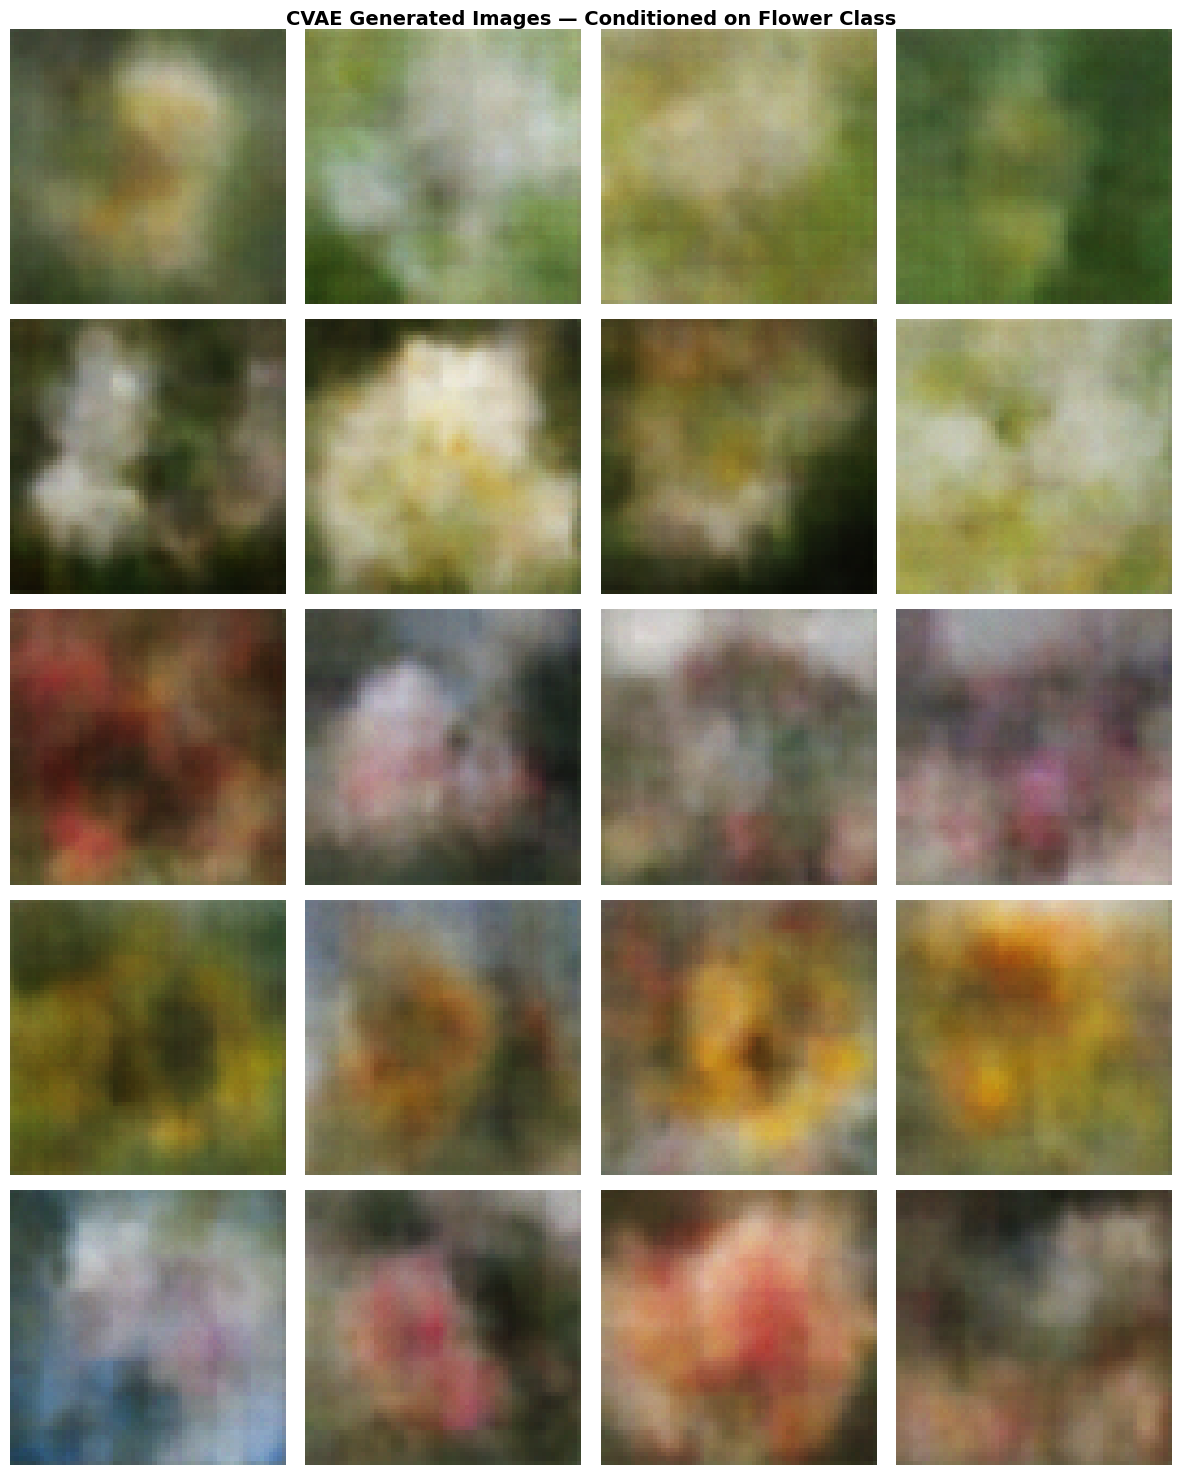

Generated images saved.


In [10]:
def generate_images_per_class(model, n_samples=4):
    """Generate n_samples images for each flower class."""
    fig, axes = plt.subplots(NUM_CLASSES, n_samples, figsize=(n_samples * 3, NUM_CLASSES * 3))

    for class_idx in range(NUM_CLASSES):
        # Create one-hot label batch
        label = tf.one_hot([class_idx] * n_samples, NUM_CLASSES)
        # Sample from prior
        z = tf.random.normal(shape=(n_samples, LATENT_DIM))
        # Decode
        generated = model.decode(z, label, training=False).numpy()

        for j in range(n_samples):
            axes[class_idx, j].imshow(generated[j])
            axes[class_idx, j].axis('off')
            if j == 0:
                axes[class_idx, j].set_ylabel(CLASS_NAMES[class_idx], fontsize=11,
                                               rotation=0, labelpad=60, va='center')

    plt.suptitle('CVAE Generated Images — Conditioned on Flower Class', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('cvae_generated_per_class.png', dpi=100, bbox_inches='tight')
    plt.show()

generate_images_per_class(cvae, n_samples=4)
print('Generated images saved.')

## 9. Latent Space Interpolation

Interpolate between two flower classes in the latent space to visualize smooth transitions.

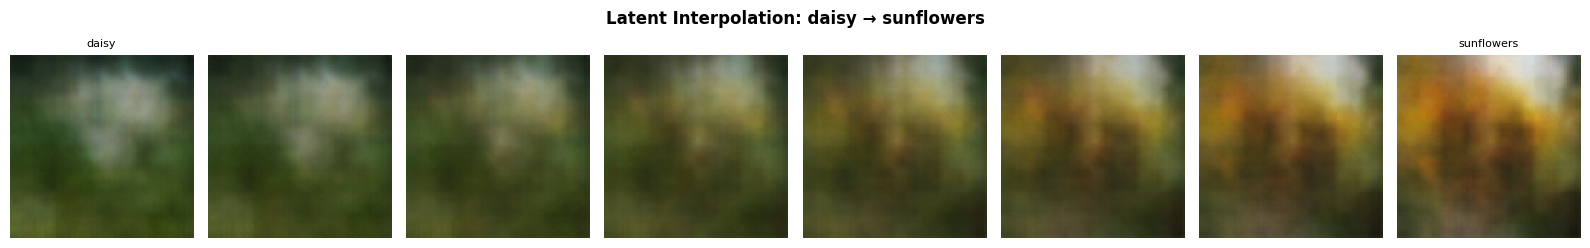

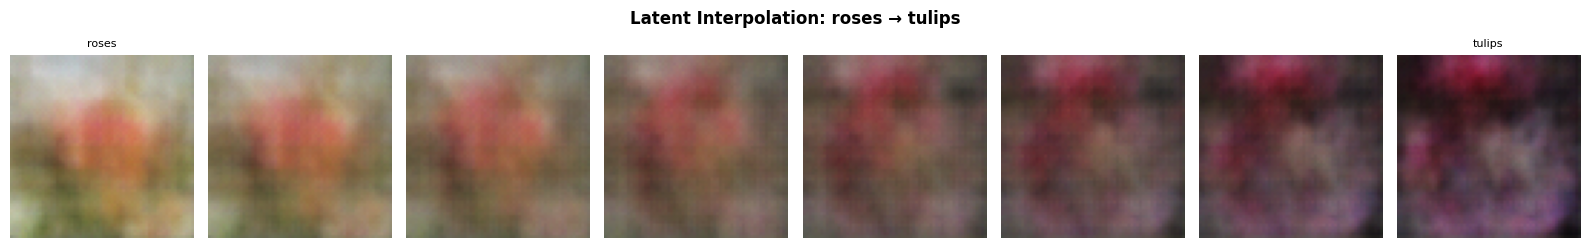

In [11]:
def interpolate_between_classes(model, class_a=0, class_b=3, steps=8):
    """Interpolate latent vectors and labels between two classes."""
    z_a = tf.random.normal([1, LATENT_DIM])
    z_b = tf.random.normal([1, LATENT_DIM])
    label_a = tf.one_hot([class_a], NUM_CLASSES)
    label_b = tf.one_hot([class_b], NUM_CLASSES)

    alphas = np.linspace(0, 1, steps)
    images = []
    for alpha in alphas:
        z_interp = (1 - alpha) * z_a + alpha * z_b
        label_interp = (1 - alpha) * label_a + alpha * label_b
        img = model.decode(z_interp, label_interp, training=False).numpy()[0]
        images.append(img)

    fig, axes = plt.subplots(1, steps, figsize=(steps * 2, 2.5))
    for i, (ax, img) in enumerate(zip(axes, images)):
        ax.imshow(img)
        ax.axis('off')
        if i == 0:
            ax.set_title(CLASS_NAMES[class_a], fontsize=8)
        elif i == steps - 1:
            ax.set_title(CLASS_NAMES[class_b], fontsize=8)

    plt.suptitle(f'Latent Interpolation: {CLASS_NAMES[class_a]} → {CLASS_NAMES[class_b]}',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('cvae_interpolation.png', dpi=100, bbox_inches='tight')
    plt.show()

interpolate_between_classes(cvae, class_a=0, class_b=3)  # daisy → sunflowers
interpolate_between_classes(cvae, class_a=2, class_b=4)  # roses → tulips

## 10. Summary

| Aspect | Details |
|---|---|
| **Dataset** | `tf_flowers` — 3,670 images, 5 classes (64×64×3) |
| **Architecture** | Encoder: 3× Conv2D → Dense; Decoder: Dense → 3× Conv2DTranspose |
| **Latent Dim** | 128 |
| **Conditioning** | One-hot class labels injected into both encoder and decoder |
| **Loss** | ELBO = Reconstruction (BCE) + KL Divergence |
| **Epochs** | 60 |
| **Key Results** | Class-conditioned generation + smooth latent interpolation between flower types |

**Differences from the TF CVAE tutorial (Fashion MNIST):**
- 3-channel colour images instead of 1-channel grayscale
- 64×64 resolution instead of 28×28
- Additional BatchNormalization layers for stable training on a small dataset
- Label embeddings via Dense layers (vs. simple concatenation in the baseline)
- 5 real-world botanical classes instead of fashion categories